In [1]:
import concurrent.futures
import time
import glob

from scipy import ndimage
from scipy.optimize import curve_fit

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyvo
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS
import shutil

In [92]:
import warnings
from matplotlib import rcParams
# Ignore all warnings
warnings.filterwarnings('ignore')

rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman',
    'mathtext.it': 'Times New Roman:italic',
    'mathtext.bf': 'Times New Roman:bold',
    'font.size': 14
})

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]


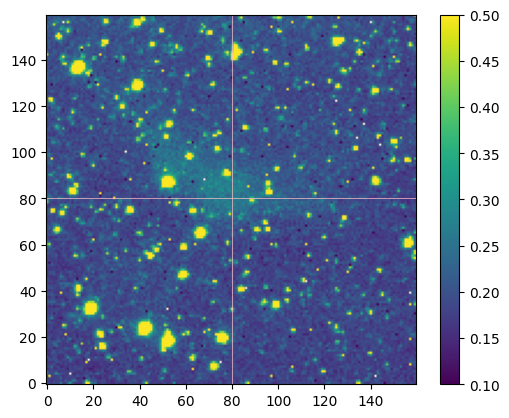

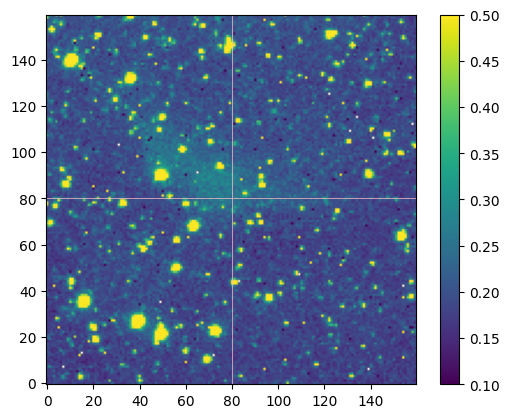

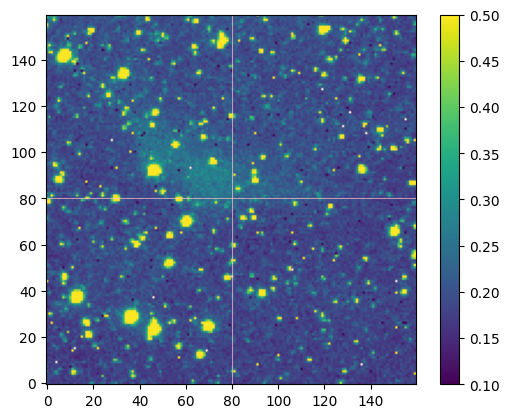

In [1008]:
allfiles = glob.glob('LDN260-SPHEREx/*.fits')
#allfiles = glob.glob('RCrA-SPHEREx/*.fits')
#allfiles = glob.glob('CrA-151-SPHEREx/*.fits')

ww, ff = [], []

for a in allfiles[5:6]:
    hdulist = fits.open(a)
    img = hdulist[1].data
    wave = hdulist[6].data
    spectral_image_header = hdulist[1].header
    wcs = WCS(spectral_image_header)
    ra, dec = wcs.wcs.crval
    x, y = wcs.world_to_pixel(SkyCoord(ra=ra, dec=dec, unit="deg"))
    spectral_wcs = WCS(header=hdulist["IMAGE"].header, fobj=hdulist, key="W")

    spectral_wcs.sip = None
    wl, bw = spectral_wcs.pixel_to_world(x, y)
    spectral_image = hdulist["IMAGE"]
    spectral_image_data = spectral_image.data
    (y, x) = np.indices(spectral_image.shape)
    spectral_coords = spectral_wcs.pixel_to_world(x, y)
    wavelength, bandwidth = spectral_coords

    coord = SkyCoord(ra=287.5840417*u.deg, dec=-37.1408333*u.deg, frame="icrs")
    #coord = SkyCoord(ra=294.2559167*u.deg, dec=7.5698889*u.deg, frame="icrs")
    #coord = SkyCoord(ra=53.3245*u.deg, dec=31.1589*u.deg, frame="icrs")
    #285.4852500 -36.9582500
    rlist = [238.5408333,238.5458333,238.5478333]   
    dlist = [-2.8263333,-2.8103333,-2.803333]
    rlist = [238.5408333,238.5328333,238.5198333]   
    dlist = [-2.8263333,-2.8263333,-2.8233333]
    rlist = [76.0617917, 76.0537917, 76.0237917]
    dlist = [25.18725, 25.20725, 25.23525]
    rlist = [251.7925000, 251.799, 251.805]   
    dlist = [-9.5835556, -9.578, -9.575]
    for rr,dd in zip(rlist,dlist):
        coord = SkyCoord(ra=rr*u.deg, dec=dd*u.deg, frame="icrs")
        #294.2529167    7.5688889
        x, y = wcs.world_to_pixel(coord)
        
        img = hdulist[1].data
        arr = img.copy()
    
        p1, p2 = int(x-80), int(x+80)
        flux = img[int(y+0.5),p1:p2]
        lam = wavelength.value[int(y+0.5),p1:p2]
        sm = 2
        flux = ndimage.gaussian_filter1d(flux, sm)
        ww.append(np.mean(lam))
        ff.append(flux)
    
        x1, x2 = int(x-80), int(x+80)
        y1, y2 = int(y-80), int(y+80)
        arr = img.copy()[y1:y2, x1:x2]
        #plt.imshow(np.log10(arr), vmin=-0.7, vmax=-0.3, origin='lower')
        plt.imshow(np.array(arr), vmin=0.1, vmax=0.5, origin='lower')
        plt.colorbar()
        
        plt.axvline(80, color='pink', lw=0.5)
        plt.axhline(80, color='pink', lw=0.5)
        plt.show()

In [769]:
rlist, dlist

([76.0617917, 76.0477917, 76.0337917],
 [25.18725, 25.201249999999998, 25.215249999999997])

In [427]:
ff = np.array(ff)
ff = ff[np.argsort(ww),:]
ww = np.sort(ww)

s1, s2 =30,31
ff[10,:] = (ff[9,:]+ff[11,:]) / 2
#ff[10,:] = np.nan
s=1

c1, c2, c3 = 71,81,90
for ind, lbl in zip([c1, c2, c3], ['left edge', 'centre', 'right edge']):
    frac = (ind-s1) / (s2-s1)
    r, g, b = frac, 0, 1-frac
    #plt.plot(ww, ff[:,ind]/np.nanmedian(ff[7:13,ind]), label=lbl, marker='d')
    plt.plot(ww, ff[:,ind]/np.nanmedian(ff[:4,ind]), label=lbl, marker='d')
#plt.axvline(ww[10], color='k')
plt.xlabel('Wavelength um')
plt.ylabel('Normalised flux')
#plt.ylim(0,2)
plt.legend()
plt.show()


x1, x2 = int(x-80), int(x+80)
y1, y2 = int(y-80), int(y+80)
arr = img.copy()[y1:y2, x1:x2]
plt.imshow(arr, vmin=0, vmax=1., origin='upper')
plt.colorbar()

[plt.axvline(a, color='pink') for a in [c1, c2, c3]]
plt.axhline(80, color='pink')
plt.show()

IndexError: index 9 is out of bounds for axis 0 with size 4

# YSO Illuminated Core:

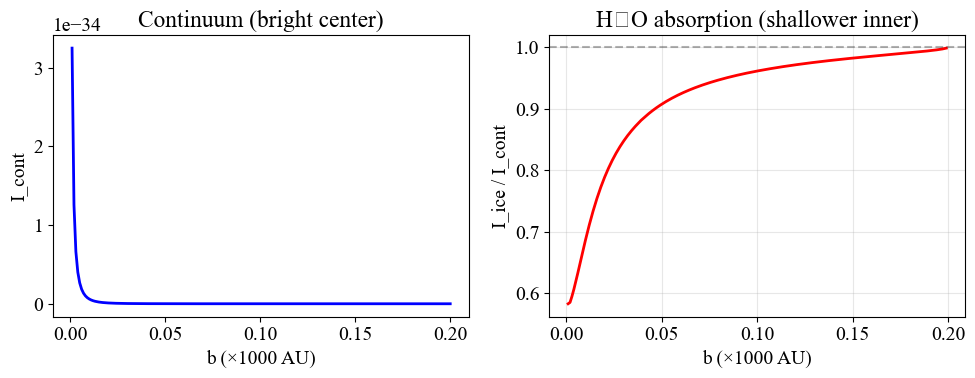

In [217]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

pccm = 3.086e18
nhgram = 1.67e-24

R_cloud = 0.2 * pccm
R0      = 0.01 * pccm
rho0 = 2e5 * nhgram
tau_cont0 = 15
tau_ice0  = 35

# Ice depletion parameters
r_warm = 0.001 * pccm  # pc, inner warm region
width  = 0.0002 * pccm  # pc, transition width

def rho(r, R0=R0):
    return rho0 * R0**2 / (r**2 + R0**2)

def ice_factor(r):
    """Ice abundance: depleted inside r_warm, full outside."""
    return 0.5 * (1 + np.tanh((r - r_warm)/width))

def phase(g1, g2, gamma, cost):
    fwd = (1-g1**2) / (1+g1**2-2*g1*cost)**1.5
    bwd = (1-g2**2) / (1+g2**2-2*g2*cost)**1.5
    return gamma*fwd + (1-gamma)*bwd

def tau_radial(r, tau_cont):
    if r <= 0:
        return 0.0
    return tau_cont * quad(lambda rp: rho(rp), 0, r)[0]

def tau_los(b, s, tau_cont, tau_ice):
    s_max = np.sqrt(max(R_cloud**2 - b**2, 0))
    if s >= s_max:
        return 0.0
    def integrand(sp):
        r = np.sqrt(b**2 + sp**2)
        return rho(r) * (tau_cont + tau_ice * ice_factor(r))  # ← ice gradient
    return quad(integrand, s, s_max)[0]

def emissivity(r, tau_cont):
    if r == 0:
        return 0.0
    J_r = np.exp(-tau_radial(r, tau_cont)) / r**2
    return rho(r) * J_r

def intensity_continuum(b):
    if b >= R_cloud:
        return 0.0
    s_max = np.sqrt(R_cloud**2 - b**2)
    def integrand(s):
        j = emissivity(np.sqrt(b**2 + s**2), tau_cont0)
        tau_l = tau_los(b, s, tau_cont0, 0)
        return j * np.exp(-tau_l) * phase(0.6, -0.6, 0.6, -s/np.sqrt(b**2 + s**2))
    return quad(integrand, -s_max, s_max)[0]

def intensity_ice(b):
    if b >= R_cloud:
        return 0.0
    s_max = np.sqrt(R_cloud**2 - b**2)
    def integrand(s):
        j = emissivity(np.sqrt(b**2 + s**2), tau_cont0)
        tau_l = tau_los(b, s, tau_cont0, tau_ice0)
        return j * np.exp(-tau_l) * phase(0.6, -0.6, 0.6, -s/np.sqrt(b**2 + s**2))
    return quad(integrand, -s_max, s_max)[0]

b_vals = np.linspace(0, R_cloud, 200)
I_cont = np.array([intensity_continuum(b) for b in b_vals])
I3 = I_cont.copy()
I_ice  = np.array([intensity_ice(b)     for b in b_vals])
ratio = I_ice / I_cont
ratio3 = ratio.copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
ax1.plot(b_vals / pccm, I_cont, 'b-', lw=2)
ax1.set_xlabel("b (×1000 AU)")
ax1.set_ylabel("I_cont")
ax1.set_title("Continuum (bright center)")

ax2.plot(b_vals / pccm, ratio, 'r-', lw=2)
ax2.axhline(1.0, color='k', ls='--', alpha=0.3)
ax2.set_xlabel("b (×1000 AU)")
ax2.set_ylabel("I_ice / I_cont")
ax2.set_title("H₂O absorption (shallower inner)")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


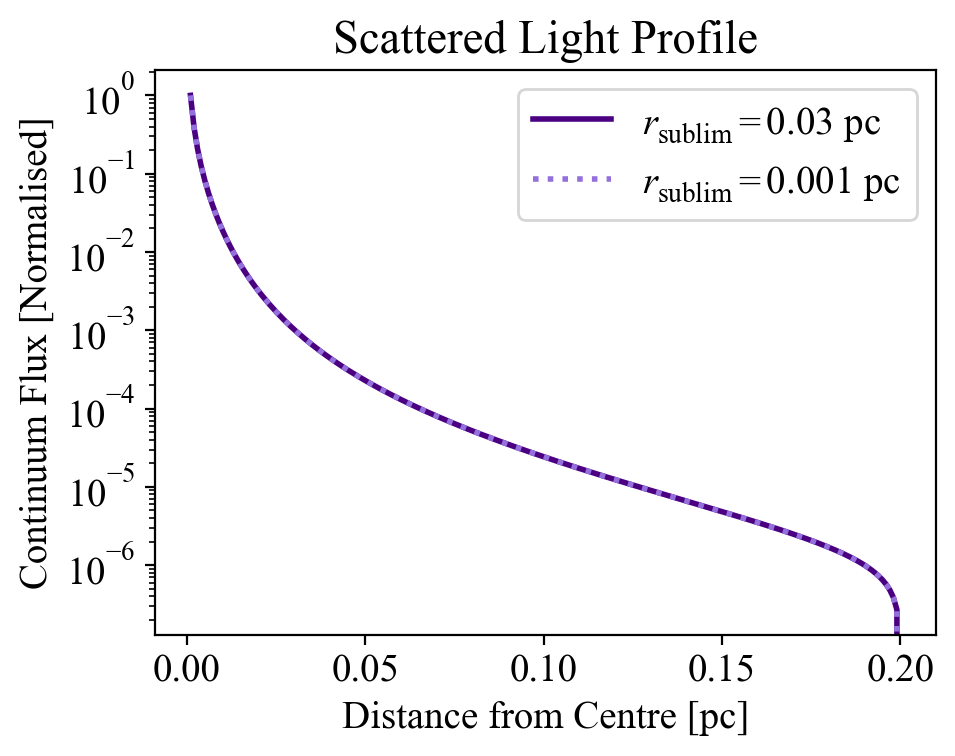

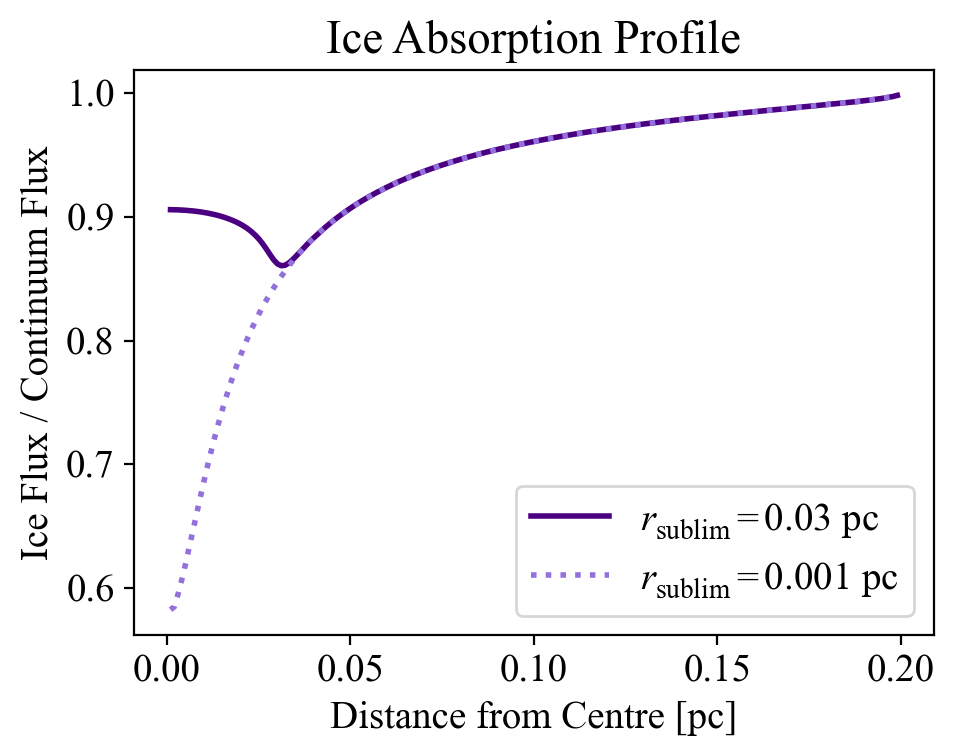

In [219]:
plt.figure(figsize=(5,4), dpi=200)
plt.plot(b_vals/pccm, I4 / np.nanmax(I4), lw=2, color='indigo',
         label=r'$r_{\mathrm{sublim}} = 0.03$ pc')
plt.plot(b_vals/pccm, I3 / np.nanmax(I3), lw=2, color='mediumpurple',
         label=r'$r_{\mathrm{sublim}} = 0.001$ pc', ls='dotted')
plt.xlabel("Distance from Centre [pc]")
plt.ylabel("Continuum Flux [Normalised]")
plt.yscale('log')
plt.title("Scattered Light Profile")
plt.legend()
plt.tight_layout()
plt.savefig('Paper1.1/protostar-cont.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

plt.figure(figsize=(5,4), dpi=200)
plt.plot(b_vals/pccm, ratio4, lw=2, color='indigo',
         label=r'$r_{\mathrm{sublim}} = 0.03$ pc')
plt.plot(b_vals/pccm, ratio3, lw=2, color='mediumpurple',
         label=r'$r_{\mathrm{sublim}} = 0.001$ pc', ls='dotted')
plt.xlabel("Distance from Centre [pc]")
plt.ylabel("Ice Flux / Continuum Flux")
plt.title("Ice Absorption Profile")
plt.legend()
plt.tight_layout()
plt.savefig('Paper1.1/protostar-ice.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

# Scattering/coreshine illuminated core:

In [76]:
rho0 * kappa_sca * r0

1.030724

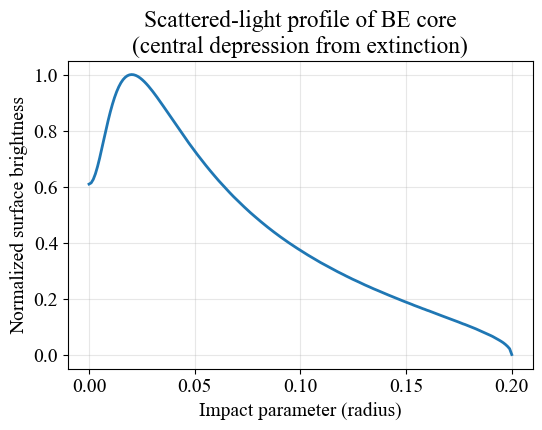

In [230]:
import numpy as np
import matplotlib.pyplot as plt

pccm = 3.086e18
nhgram = 1.67e-24

# -----------------------------
# Grid and geometry
# -----------------------------
R_max = 0.2*pccm          # core radius (arbitrary units)
nr = 500
ns = 800

r = np.linspace(0, R_max, nr)
b_vals = np.linspace(0, R_max, 200)

# Line-of-sight coordinate
s = np.linspace(-R_max, R_max, ns)

# -----------------------------
# Bonnor–Ebert–like density profile
# (analytic approximation)
# -----------------------------
rho0 = 1e6 * nhgram
r0 = 0.01*pccm             # flat inner radius
rho = rho0 / (1 + (r / r0)**2)
rhosat = 3e5 * nhgram
g = 0.6

# Interpolation helper
def rho_interp(x):
    return np.interp(x, r, rho, left=0, right=0)

# -----------------------------
# Dust properties
# -----------------------------
kappa_abs = 10      # absorption opacity
kappa_sca = 5      # scattering opacity
kappa_ext = kappa_abs + kappa_sca
albedo = kappa_sca / kappa_ext
switch = 0


# -----------------------------
# Surface brightness
# -----------------------------
I = []

for b in b_vals:
    r_los = np.sqrt(b**2 + s**2)
    inside = r_los <= R_max

    r_use = r_los[inside]
    s_use = s[inside]

    # Optical depth from surface -> scattering point
    tau_in = np.zeros_like(r_use)
    for i in range(len(r_use)):
        path = np.sqrt(b**2 + s_use[:i+1]**2)
        rhor = rho_interp(path)
        #tau_in[i] = np.trapz(rhor, s_use[:i+1]) * kappa_ext
        rhoeff = rhor * ((1-albedo) / (1+switch*rhor/rhosat) + albedo)
        tau_in[i] = np.trapz(rhoeff, s_use[:i+1]) * kappa_ext

    # Optical depth from scattering point -> observer
    tau_out = np.zeros_like(r_use)
    for i in range(len(r_use)):
        path = np.sqrt(b**2 + s_use[i:]**2)
        rhor = rho_interp(path)
        #tau_out[i] = np.trapz(rhor, s_use[i:]) * kappa_ext
        rhoeff = rhor * ((1-albedo) / (1+switch*rhor/rhosat) + albedo)
        tau_out[i] = np.trapz(rhoeff, s_use[i:]) * kappa_ext

    # Incident radiation field
    J_inc = np.exp(-tau_in)

    # Scattered emissivity
    emissivity = rho_interp(r_use) * kappa_sca * J_inc * (1 - g) / (1 + g)

    # Attenuation after scattering
    contrib = emissivity * np.exp(-tau_out)

    I.append(np.trapz(contrib, s_use))

I = np.array(I)
I_cont = I.copy()

# Normalize
I /= I.max()

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(b_vals/pccm, I, lw=2)
plt.xlabel("Impact parameter (radius)")
plt.ylabel("Normalized surface brightness")
plt.title("Scattered-light profile of BE core\n(central depression from extinction)")
plt.grid(alpha=0.3)
plt.show()


In [79]:
130 * 1/60*3.14/180

0.03779629629629629

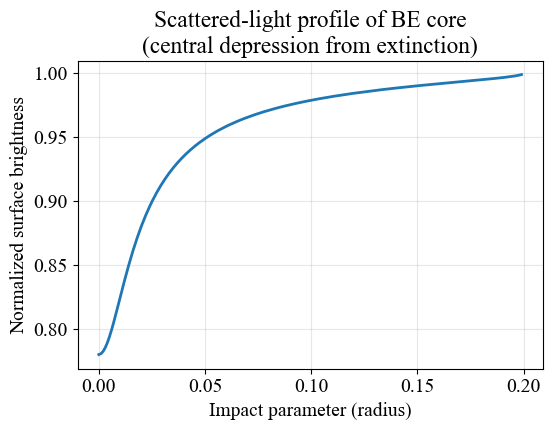

In [212]:
plt.figure(figsize=(6,4))
plt.plot(b_vals/pccm, I_ice/I_cont, lw=2)
plt.xlabel("Impact parameter (radius)")
plt.ylabel("Normalized surface brightness")
plt.title("Scattered-light profile of BE core\n(central depression from extinction)")
#plt.yscale('log')
plt.grid(alpha=0.3)
plt.show()


In [213]:
I2_ice = I_ice.copy()
I2_cont = I_cont.copy()

In [185]:
# For dense: rho0 = 1e6, 
# For sparse: rho0 = 1e5

# Ice absorption: kappa_abs = 60, kappa_sca = 5
# Continuum absorption: kappa_abs = 10, kappa_sca = 5

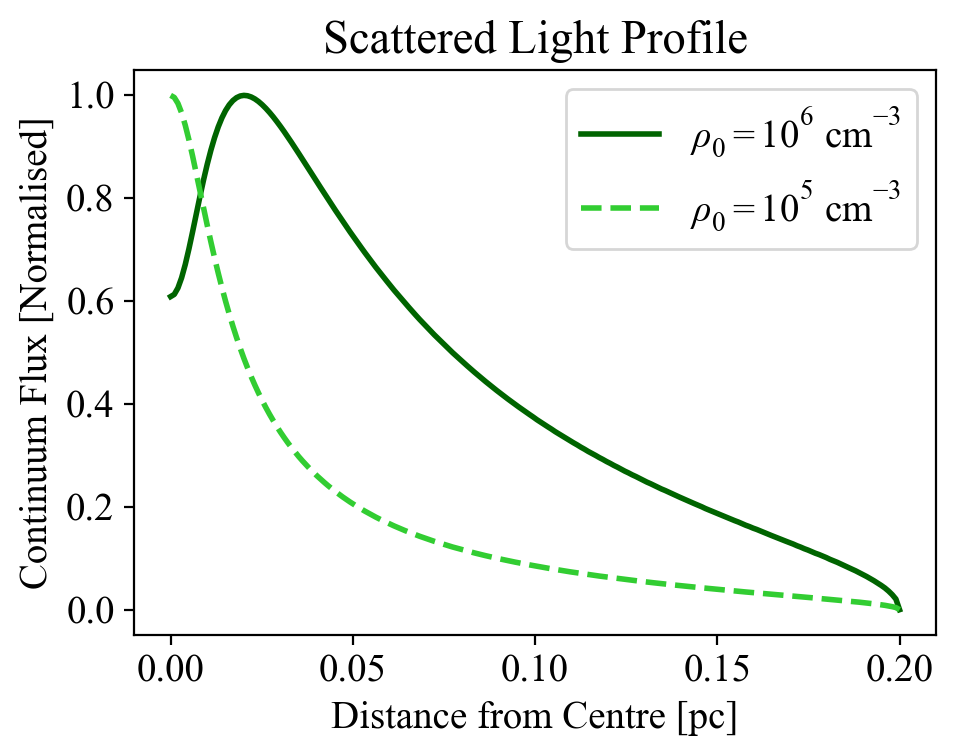

In [214]:
plt.figure(figsize=(5,4), dpi=200)
plt.plot(b_vals/pccm, I1_cont / np.max(I1_cont), lw=2, color='darkgreen',
         label=r'$\rho_0 = 10^6$ cm$^{-3}$')
plt.plot(b_vals/pccm, I2_cont / np.max(I2_cont), lw=2, color='limegreen',
         label=r'$\rho_0 = 10^5$ cm$^{-3}$', ls='--')
plt.xlabel("Distance from Centre [pc]")
plt.ylabel("Continuum Flux [Normalised]")
plt.title("Scattered Light Profile")
plt.legend()
plt.tight_layout()
plt.savefig('Paper1.1/coreshine-cont.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

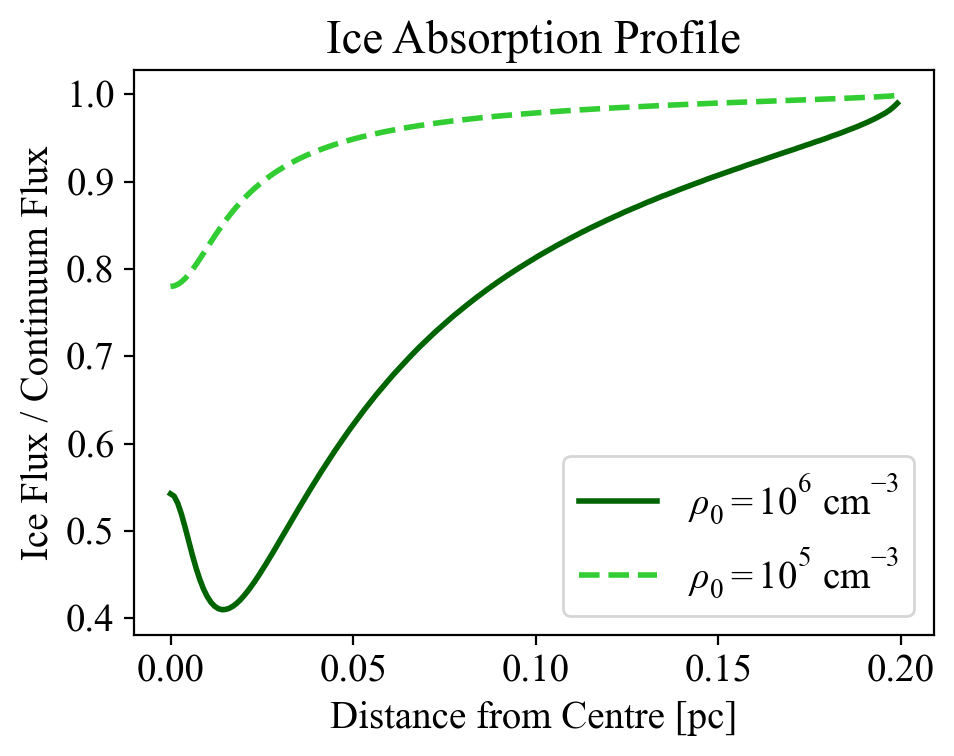

In [215]:
plt.figure(figsize=(5,4), dpi=200)
plt.plot(b_vals/pccm, I1_ice / I1_cont, lw=2, color='darkgreen',
         label=r'$\rho_0 = 10^6$ cm$^{-3}$')
plt.plot(b_vals/pccm, I2_ice / I2_cont, lw=2, color='limegreen',
         label=r'$\rho_0 = 10^5$ cm$^{-3}$', ls='--')
plt.xlabel("Distance from Centre [pc]")
plt.ylabel("Ice Flux / Continuum Flux")
plt.title("Ice Absorption Profile")
plt.legend()
plt.tight_layout()
plt.savefig('Paper1.1/coreshine-ice.pdf', bbox_inches='tight', pad_inches=0)
plt.show()